In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import clear_output
import time

In [2]:
df = load_iris(as_frame=True)
data = df.frame

In [3]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


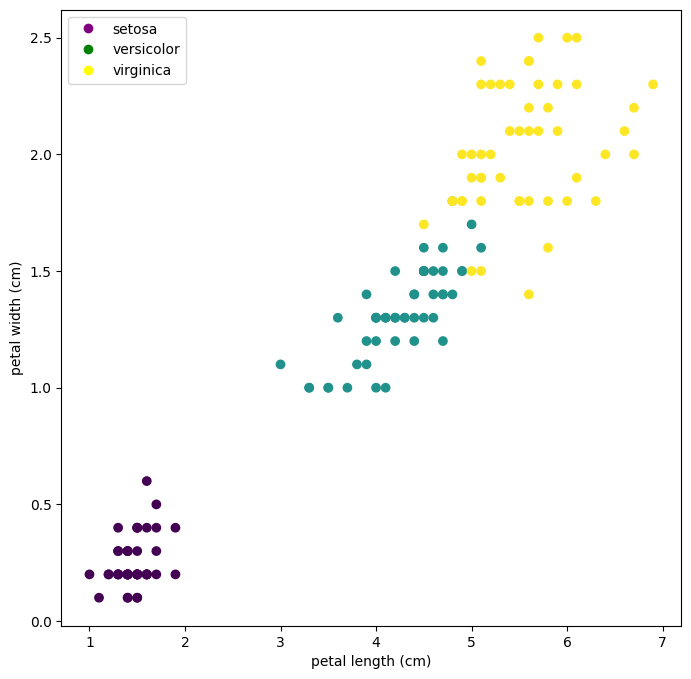

In [4]:
plt.figure(figsize=(8,8))
plt.scatter(x=data["petal length (cm)"], y=data["petal width (cm)"], c=data["target"])

plt.ylabel("petal width (cm)")
plt.xlabel("petal length (cm)")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=label)
    for color, label in zip(['purple', 'green', 'yellow'], ["setosa", "versicolor", "virginica"])
]
plt.legend(handles=legend_elements)
plt.show()

In [5]:
df.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

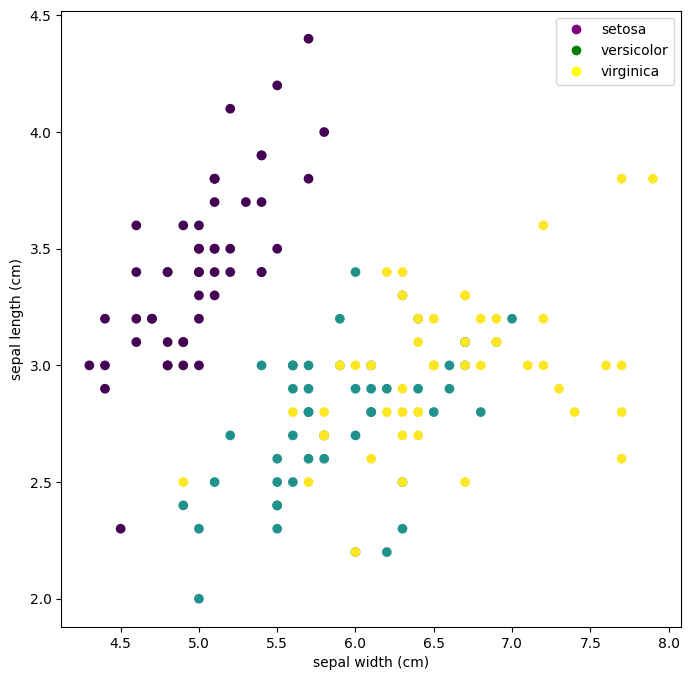

In [6]:
plt.figure(figsize=(8,8))
plt.scatter(x=data["sepal length (cm)"], y=data["sepal width (cm)"], c=data["target"])

plt.ylabel("sepal length (cm)")
plt.xlabel("sepal width (cm)")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=label)
    for color, label in zip(['purple', 'green', 'yellow'], ["setosa", "versicolor", "virginica"])
]
plt.legend(handles=legend_elements)
plt.show()

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [8]:
b_data = data[(data["target"] == 0) | (data["target"] == 2)]

In [9]:
b_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
b_data.shape, data.shape

((100, 5), (150, 5))

In [11]:
b_data["target"].unique()

array([0, 2])

In [12]:
# setting a random hyperplane
w = np.random.randn(1)
b = np.random.randn(1)

w, b

(array([1.21474969]), array([-0.63657387]))

In [13]:
def hyperplane(w, b, x):
    return (-(w[0] * x + b) / w[1]).item()

### Preparing the data

In [15]:
columns = ["sepal length (cm)", "sepal width (cm)"]
X = b_data[columns]
Y = b_data["target"]

In [16]:
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [17]:
X.shape

(100, 2)

In [18]:
Y = Y.replace({0:-1, 2:1})

In [19]:
X = X.to_numpy()
Y = Y.to_numpy()

In [20]:
Y = Y.reshape((X.shape[0], 1))

In [21]:
X.shape, Y.shape

((100, 2), (100, 1))

## Initializing w, b

In [22]:
w = np.zeros(shape=(X.shape[1], 1))
b = np.zeros(shape=(1, 1))
w,b

(array([[0.],
        [0.]]),
 array([[0.]]))

In [23]:
Y.shape

(100, 1)

In [25]:
def calculate_loss(w, b, X, Y, C=1.0):
    hinge_loss = np.maximum(0, 1 - Y * (X @ w + b)).sum()
    loss = 0.5 * (w.T @ w) + C * hinge_loss
    return loss.item()

In [26]:
calculate_loss(
    w=w,
    b=b,
    X=X,
    Y=Y,
)

100.0

In [27]:
def check(w, b, X, Y):
    return Y * (X @ w + b) >= 1

In [28]:
r = check(
    w=w,
    b=b,
    X=X,
    Y=Y
).squeeze()

In [29]:
r.shape

(100,)

In [42]:
def calculating_gradients(w, b, X, Y, C):
    result = check(w, b, X, Y).squeeze()
    dl_dw = w - C * (X[~result] * Y[~result]).sum(axis=0, keepdims=True).T / X.shape[0]
    dl_db = -C * Y[~result].sum()
    return dl_dw, dl_db

In [43]:
def update_params(w, b, X, Y, C, lr=3e-2):
    dl_dw, dl_db = calculating_gradients(w, b, X, Y, C)
    new_w = w - lr * dl_dw
    new_b = b - lr * dl_db
    return new_w, new_b

In [44]:
def train_hard_margin_svm(X, Y, C, lr=3e-2, epochs=10):
    w = np.zeros(shape=(X.shape[1], 1))
    b = np.zeros(shape=(1, 1))
    x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

    for epoch in range(epochs):
        w, b = update_params(w, b, X, Y, C, lr)
        cost = calculate_loss(w, b, X, Y, C)
        y_range = [hyperplane(w, b, x) for x in x_range]

        clear_output(wait=True)
        plt.figure(figsize=(6, 4))
        plt.scatter(X[:, 0], X[:, 1], c=Y.squeeze())
        plt.plot(x_range, y_range, 'r-', label='hyperplane')
        plt.xlabel("sepal length (cm)")
        plt.ylabel("sepal width (cm)")
        plt.title(f"Epoch {epoch+1}/{epochs} — Loss: {cost:.4f}")
        plt.legend()
        plt.show()
        time.sleep(1)

    return w, b

In [37]:
# Standardize
X = (X - X.mean(axis=0))/X.std(axis=0)

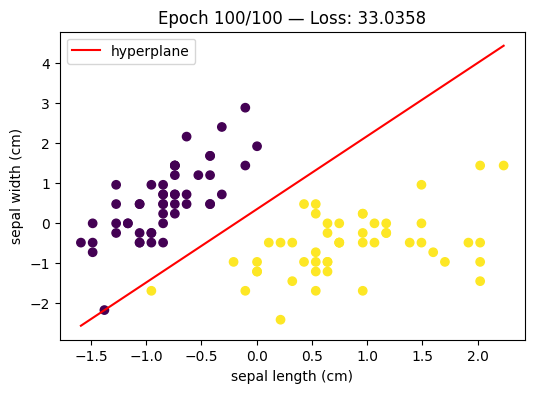

In [46]:
w, b = train_hard_margin_svm(X, Y, C=1.0, lr=0.03, epochs=100)

In [47]:
w,b

(array([[ 0.62917693],
        [-0.3446377 ]]),
 array([[0.12]]))